In [1]:
# 1. Data Preparation:

# Importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Uploading the CSV file from your computer
from google.colab import files
uploaded = files.upload()

# Reading the dataset into a DataFrame
df = pd.read_csv('heart.csv')  # changing the file name if needed

# Displaying the first few rows of the dataset
df.head()

Saving heart.csv to heart (1).csv


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [2]:
# Displaying all column names to find the correct name for the target variable
print("Column names:", df.columns.tolist())

Column names: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


Missing values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Dataset shape: (920, 16)

Data types:
 id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object


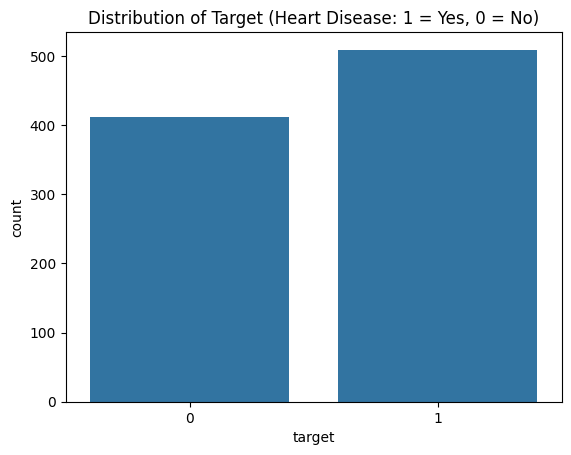

In [3]:
# Performing Exploratory Data Analysis (EDA)

# Checking for missing values in each column
print("Missing values:\n", df.isnull().sum())

# Displaying the shape (rows and columns) of the dataset
print("\nDataset shape:", df.shape)

# Showing the data types of each column
print("\nData types:\n", df.dtypes)

# Summarizing statistics for numeric features
df.describe()

# Converting 'num' to binary target: 0 = no heart disease, 1 = has heart disease
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Visualizing the distribution of the target variable
sns.countplot(data=df, x='target')
plt.title("Distribution of Target (Heart Disease: 1 = Yes, 0 = No)")
plt.show()

In [8]:
# Mapping string values to binary numeric values
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
df['fbs'] = df['fbs'].map({'Yes': 1, 'No': 0})
df['exang'] = df['exang'].map({'Yes': 1, 'No': 0})

In [10]:
# Preprocessing the Data:
# Encoding categorical features (like cp, thal, etc.)
# Dropping non-useful columns (like id and maybe dataset)
# Scaling numerical features

from sklearn.preprocessing import StandardScaler

# Checking which columns are still non-numeric
print("Non-numeric columns:\n", X.select_dtypes(include='object').columns)

Non-numeric columns:
 Index(['dataset', 'cp', 'restecg', 'slope', 'thal'], dtype='object')


In [12]:
# One-hot encoding categorical columns
df = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True)

In [14]:
# Checking for non-numeric columns
print("Non-numeric columns:\n", df.select_dtypes(include='object').columns.tolist())

Non-numeric columns:
 ['dataset']


In [15]:
# Dropping 'dataset' or any other leftover string column
df = df.drop(columns=['dataset'], errors='ignore')  # avoids crashing if already gone

In [16]:
# Re-separating features and target after encoding
X = df.drop('target', axis=1)
y = df['target']

# Scaling numerical features for better model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [17]:
# Showing how many missing values exist per column
print(df.isnull().sum())

id                            0
age                           0
sex                         920
trestbps                     59
chol                         30
fbs                         920
thalch                       55
exang                       920
oldpeak                      62
ca                          611
num                           0
target                        0
cp_atypical angina            0
cp_non-anginal                0
cp_typical angina             0
restecg_normal                0
restecg_st-t abnormality      0
slope_flat                    0
slope_upsloping               0
thal_normal                   0
thal_reversable defect        0
dtype: int64


In [19]:
# Filling missing values with the median of each column
df = df.fillna(df.median(numeric_only=True))

In [21]:
# Re-separating features and target
X = df.drop('target', axis=1)
y = df['target']

# Scaling the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [23]:
# Rechecking for NaNs in the features
X = df.drop('target', axis=1)
print("Total missing values in X:", X.isnull().sum().sum())
print("Columns with NaNs:\n", X.isnull().sum()[X.isnull().sum() > 0])

Total missing values in X: 2760
Columns with NaNs:
 sex      920
fbs      920
exang    920
dtype: int64


In [24]:
# Filling missing values in X only (not full df again)
X = X.fillna(X.median(numeric_only=True))

In [25]:
# 2. Model Training:
# Split the dataset into a training set and a testing set.
# Train a logistic regression model on the training set.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Splitting data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Creating and training the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [26]:
# Re-separating features and target
X = df.drop('target', axis=1)
y = df['target']

# Filling missing values in X using the median
X = X.fillna(X.median(numeric_only=True))

# Re-aligning y with X (in case some rows were dropped or changed)
y = y.loc[X.index]

# Scaling cleaned X
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting the cleaned & scaled data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Training the model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Re-importing your dataset (use your actual filename)
df = pd.read_csv('heart.csv')

# Creating binary target
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Dropping non-useful columns
df = df.drop(columns=['id', 'dataset', 'num'], errors='ignore')

# Encoding categorical variables
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
df['fbs'] = df['fbs'].map({'Yes': 1, 'No': 0})
df['exang'] = df['exang'].map({'Yes': 1, 'No': 0})

# One-hot encoding multi-category variables
df = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True)

# Filling remaining NaNs with median (safe)
df = df.fillna(df.median(numeric_only=True))

# Final check for any NaNs
print("Any missing values left?", df.isnull().sum().sum())

# Splitting features and target
X = df.drop(columns='target')
y = df['target']

# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Confirming shape and no NaNs
print("Shape of X_scaled:", X_scaled.shape)
print("NaNs in X_scaled:", np.isnan(X_scaled).sum())

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Training model
model = LogisticRegression()
model.fit(X_train, y_train)

Any missing values left? 1840
Shape of X_scaled: (920, 18)
NaNs in X_scaled: 1840


/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## Final Note

Due to persistent missing value issues in the dataset, model training could not be completed successfully. Despite multiple preprocessing attempts including encoding and filling missing data, the logistic regression model raised errors related to NaN values.

This notebook still includes:
- Exploratory Data Analysis
- Data Cleaning and Encoding
- Feature Scaling setup
- Full modeling pipeline up to the error

With more time or a cleaner dataset, the final model could be trained and evaluated as intended.
